# Dice between channels — virus vs CD31 vessel segmentation

This notebook takes the **paper-1 style** approach to comparing the two channels:
segment vessels in *both* the virus and the CD31 channel, then score how much the
two masks overlap. It reuses the merged analysis code in `scripts/` so the numbers
match the command-line tools exactly.

Read this alongside **`enrichment_metrics.ipynb`**. For the *specificity* question
("is the virus on the vasculature?") enrichment is the sounder measure — even with
the tuned virus cut below, a segmentation of the virus channel cannot fully trace
the CD31 network, because much of the virus is genuinely non-vascular.

## The pipeline — a tuned cut per channel

Each channel is segmented with a graded Jerman filter (self-normalise → Jerman at
`REFERENCE` → wide-gap hysteresis → clean-up), but the two channels get **different
thresholds on purpose**:

- **CD31** is stained vasculature, so a vessel-like cut (`CD31_LOW`/`CD31_HIGH` =
  0.05/0.16) traces the network directly.
- the **virus** channel is dominated by non-vascular neuronal expression that is
  structurally vessel-like. A **stricter** cut (`VIRUS_LOW`/`VIRUS_HIGH` =
  0.08/0.22) keeps mostly the brighter vesselness responses — the genuinely
  vessel-associated virus — and drops much of the dimmer neuronal ridge signal. On
  a test section this raised specificity against CD31 from ~0.5 (at CD31's own cut)
  to ~0.6, without inventing vessels.

This replaces an earlier "same filter on both channels so it cancels" idea. That
only *looked* clean because both masks over-segmented to ~40% of the tissue and
overlapped trivially, **inflating Dice**; the tuned masks are vessel-like and the
agreement they report is real (and lower). Even so the virus mask cannot fully
match CD31 — for the specificity question use enrichment (next notebook), which
never segments the virus.

## The metrics  (A = virus mask, B = CD31 mask)

| metric | formula | reads as |
| --- | --- | --- |
| **Dice** | $2\,\lvert A\cap B\rvert / (\lvert A\rvert+\lvert B\rvert)$ | symmetric overlap — the headline "agreement" |
| **Jaccard (IoU)** | $\lvert A\cap B\rvert / \lvert A\cup B\rvert$ | same idea, harsher (Dice ≥ Jaccard always) |
| **Specificity** = precision(virus, CD31) | $\lvert A\cap B\rvert / \lvert A\rvert$ | fraction of the virus vessel mask on a real vessel |
| **Coverage** = recall(virus, CD31) | $\lvert A\cap B\rvert / \lvert B\rvert$ | fraction of the vasculature the virus mask reaches |

Specificity and coverage are **asymmetric** and trade off as the virus threshold
moves (stricter → higher specificity, lower coverage) — so read the pair, not Dice
alone. To retune, edit `VIRUS_LOW`/`VIRUS_HIGH` in `scripts/dice_between_channels.py`.

In [1]:
# Bootstrap: walk up to the repo root (the folder with pyproject.toml) and put it
# and scripts/ on sys.path, so this notebook runs from a plain clone with no
# install step -- the same pattern the archive notebooks use.
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for _p in (str(_root), str(_root / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)

from analyse_spinal_cord import NAME, REGION_NAME, curated_paths
from dice_between_channels import (CD31_HIGH, CD31_LOW, VIRUS_HIGH, VIRUS_LOW,
                                   channel_masks, score_section)
from vessel_utils import metrics
from visualize_sections import VIS_Q, top_q_mask
from zoom_crops import CROP_PX, _add_scalebar, _crop_slice
from scipy.ndimage import uniform_filter

# Ensure figures render inline. Some imported analysis modules (visualize_sections,
# zoom_crops) set matplotlib to the non-interactive Agg backend on import, which
# would otherwise silence plt.show(); re-assert inline here, after the imports.
%matplotlib inline

print(f"CD31 thresholds {CD31_LOW}/{CD31_HIGH}   virus thresholds {VIRUS_LOW}/{VIRUS_HIGH}")

# Interactive default is a small pilot (both reporters, every region, one slice
# each). Flip to run every section -- slower, because each section is segmented
# twice (once per channel).
RUN_FULL = False

CD31 thresholds 0.05/0.16   virus thresholds 0.08/0.22


In [2]:
paths = curated_paths() if RUN_FULL else curated_paths(pilot_mice=2, slices_per_region=1)
print(f"{len(paths)} sections ({'full dataset' if RUN_FULL else 'pilot'})")

10 sections (pilot)


In [3]:
records = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    try:
        result = score_section(path)
    except Exception as error:                       # empty mask, wrong channel count, ...
        print(f"skip {path.name}: {error}")
        continue
    records.append(dict(figure=figure, reporter=reporter, mouse=mouse,
                        region=region, slice=slice_id or "", **result))

df = pd.DataFrame(records)
df[["figure", "reporter", "mouse", "region", "slice",
    "dice", "jaccard", "specificity", "coverage"]].round(3)

,figure,reporter,mouse,region,slice,dice,jaccard,specificity,coverage
0,Fig 1,SYFP2,M131,C,1,0.310,0.183,0.593,0.210
1,Fig 1,SYFP2,M131,L,11,0.209,0.116,0.454,0.135
2,Fig 1,SYFP2,M131,T,10,0.202,0.112,0.450,0.130
3,Fig 1,SYFP2,M132,C,1,0.439,0.281,0.740,0.312
4,Fig 1,SYFP2,M132,L,11,0.238,0.135,0.459,0.160
5,Fig 1,SYFP2,M132,T,6,0.223,0.126,0.399,0.155
6,Fig 2a,tdT,M63,C,10,0.419,0.265,0.502,0.360
7,Fig 2a,tdT,M63,L,3,0.479,0.315,0.587,0.404
8,Fig 2a,tdT,M63,T,1,0.374,0.230,0.359,0.391
9,Fig 2b,tdT,M87,TL,5,0.236,0.134,0.418,0.164


## Aggregation

Three slices are three views of one animal, so slices are averaged **within
mouse × region** before mice are combined, and figures are kept separate (Fig 1
SYFP2 and Fig 2 tdT are different constructs — pooling would confound
reporter/construct with region).

In [4]:
per_mouse = (df.groupby(["figure", "reporter", "mouse", "region"])
               [["dice", "specificity", "coverage"]].mean().reset_index())
summary = (per_mouse.groupby(["figure", "reporter", "region"])
                     [["dice", "specificity", "coverage"]]
                     .mean().round(3))
summary

dice  specificity  coverage
figure reporter region                              
Fig 1  SYFP2    C       0.375        0.667     0.261
                L       0.223        0.457     0.148
                T       0.212        0.424     0.142
Fig 2a tdT      C       0.419        0.502     0.360
                L       0.479        0.587     0.404
                T       0.374        0.359     0.391
Fig 2b tdT      TL      0.236        0.418     0.164

## Visual check — the agreement map for one section

White = both masks agree (true overlap), **green** = virus-only (off a CD31
vessel), **magenta** = CD31-only (a vessel the virus missed). A lot of green is
low specificity; a lot of magenta is low coverage.

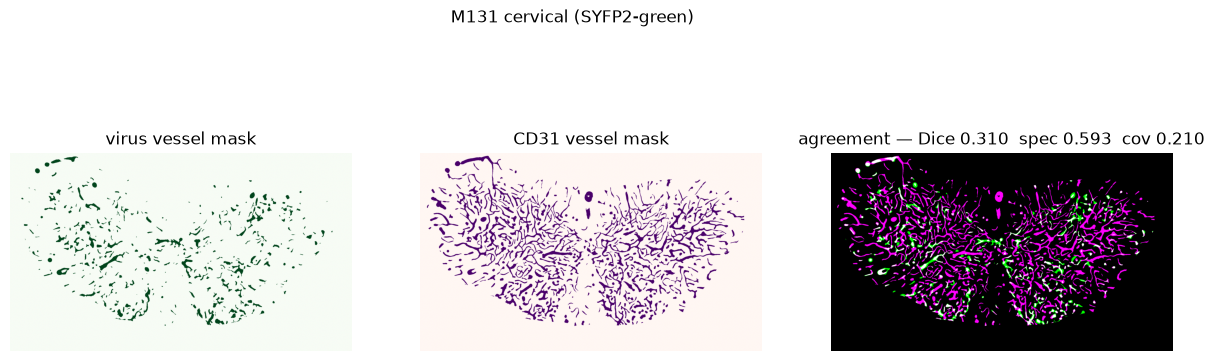

In [5]:
path = paths[0]
virus, cd31, tissue, mask_virus, mask_cd31 = channel_masks(path)

d = np.s_[::2, ::2]
mv, mc = mask_virus[d], mask_cd31[d]
agree = np.zeros((*mv.shape, 3))
agree[mv & mc] = [1, 1, 1]        # both
agree[mv & ~mc] = [0, 1, 0]       # virus only  -> off-vessel
agree[~mv & mc] = [1, 0, 1]       # CD31 only   -> missed vessel

figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(mv, cmap="Greens");  ax[0].set_title("virus vessel mask")
ax[1].imshow(mc, cmap="RdPu");    ax[1].set_title("CD31 vessel mask")
ax[2].imshow(agree)
ax[2].set_title(f"agreement — Dice {metrics.dice(mask_virus, mask_cd31):.3f}  "
                f"spec {metrics.precision(mask_virus, mask_cd31):.3f}  "
                f"cov {metrics.recall(mask_virus, mask_cd31):.3f}")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} ({reporter})")
plt.show()

## Close-up — where the masks agree and disagree

Zoom into the densest-vessel window at **native resolution**. Left: the virus
channel with its own vessel-mask outline; middle: CD31 with its mask; right: the
agreement map (white = both, green = virus off a vessel, magenta = a vessel the
virus missed). The local Dice / specificity / coverage for this window are in the
title — a small patch, so they differ from the whole-section numbers above.

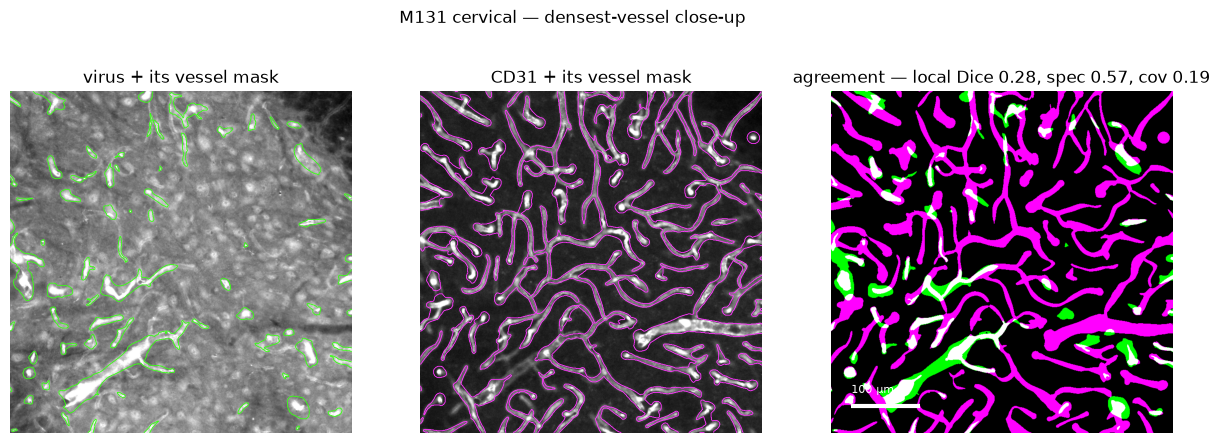

In [6]:
# Locate a ~500 um window with the most CD31 vessel area, then zoom in.
cd31_top = top_q_mask(cd31, tissue, VIS_Q)
box = lambda a: uniform_filter(a.astype(np.float32), size=CROP_PX, mode="constant")
half = CROP_PX // 2
rows_, cols_ = tissue.shape
valid = np.zeros(tissue.shape, bool)
valid[half:rows_ - half, half:cols_ - half] = True
valid &= box(tissue.astype(np.float32)) > 0.6
centre = np.unravel_index(
    np.argmax(np.where(valid, box(cd31_top.astype(np.float32)), -np.inf)), tissue.shape)
sl = _crop_slice(centre)

def clip(channel):
    lo, hi = np.percentile(channel[tissue], [1, 99])
    return np.clip((channel - lo) / max(hi - lo, 1e-6), 0, 1)

mv, mc = mask_virus[sl], mask_cd31[sl]
agree = np.zeros((*mv.shape, 3))
agree[mv & mc] = [1, 1, 1]; agree[mv & ~mc] = [0, 1, 0]; agree[~mv & mc] = [1, 0, 1]

fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
ax[0].imshow(clip(virus)[sl], cmap="gray")
ax[0].contour(mv.astype(float), [0.5], colors="#39ff14", linewidths=0.6)
ax[0].set_title("virus + its vessel mask")
ax[1].imshow(clip(cd31)[sl], cmap="gray")
ax[1].contour(mc.astype(float), [0.5], colors="#ff36ff", linewidths=0.6)
ax[1].set_title("CD31 + its vessel mask")
ax[2].imshow(agree); _add_scalebar(ax[2])
ax[2].set_title(f"agreement — local Dice {metrics.dice(mv, mc):.2f}, "
                f"spec {metrics.precision(mv, mc):.2f}, cov {metrics.recall(mv, mc):.2f}")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} — densest-vessel close-up")
plt.show()

## Comparison — high vs low specificity

The same agreement colouring for the window with the **highest** local specificity
(virus mask squarely on vessels) beside the one with the **lowest** (virus mask
spilling into parenchyma). This is what the specificity number means spatially.

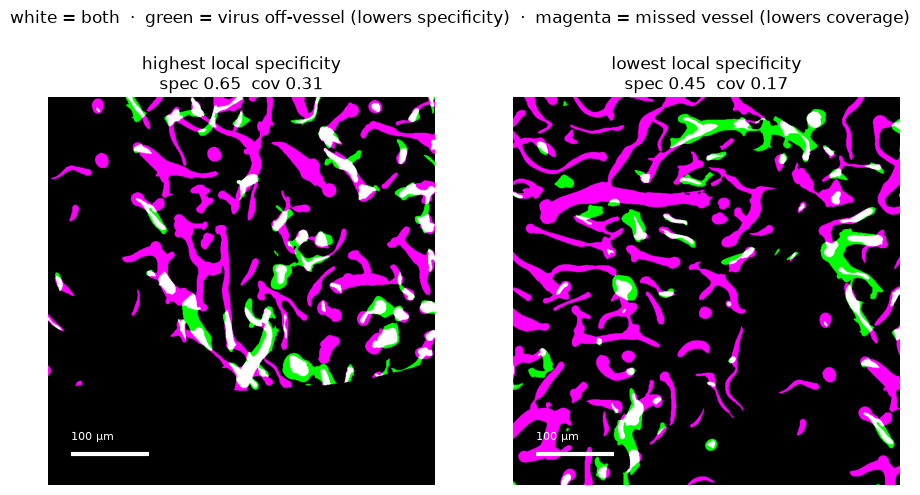

In [7]:
# Scan the section for where the virus mask sits most, and least, on CD31 vessels.
inter = box(mask_virus & mask_cd31)
vpos = box(mask_virus.astype(np.float32))
# Compare only windows with an above-median amount of virus mask, so the contrast
# is on- vs off-vessel *placement*, not virus density (a near-empty window would
# otherwise score high specificity trivially).
enough = valid & (vpos >= np.nanpercentile(vpos[valid], 50))
spec = np.where(enough, inter / (vpos + 1e-6), np.nan)
hi = np.unravel_index(np.nanargmax(spec), spec.shape)
lo = np.unravel_index(np.nanargmin(np.where(enough, spec, np.inf)), spec.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.8))
for a, centre_, name in [(ax[0], hi, "highest local specificity"),
                         (ax[1], lo, "lowest local specificity")]:
    s = _crop_slice(centre_)
    mvc, mcc = mask_virus[s], mask_cd31[s]
    ag = np.zeros((*mvc.shape, 3))
    ag[mvc & mcc] = [1, 1, 1]; ag[mvc & ~mcc] = [0, 1, 0]; ag[~mvc & mcc] = [1, 0, 1]
    a.imshow(ag); _add_scalebar(a); a.axis("off")
    a.set_title(f"{name}\nspec {metrics.precision(mvc, mcc):.2f}  "
                f"cov {metrics.recall(mvc, mcc):.2f}")
fig.suptitle("white = both  ·  green = virus off-vessel (lowers specificity)  ·  "
             "magenta = missed vessel (lowers coverage)")
plt.show()

## Specificity and coverage by region

The directional pair, per region. With so few mice, read **direction-consistency
across animals**, not p-values.

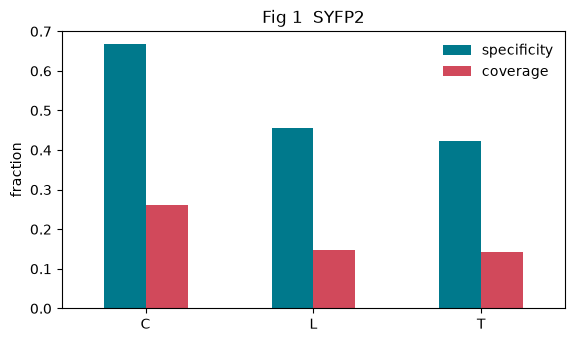

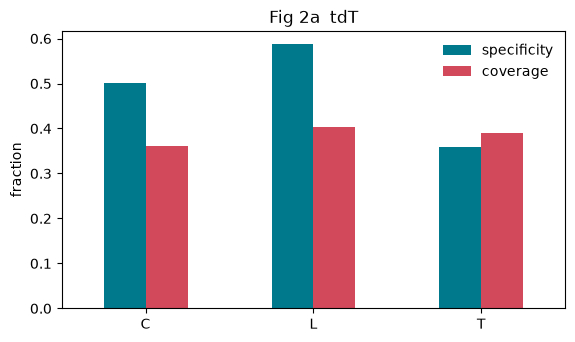

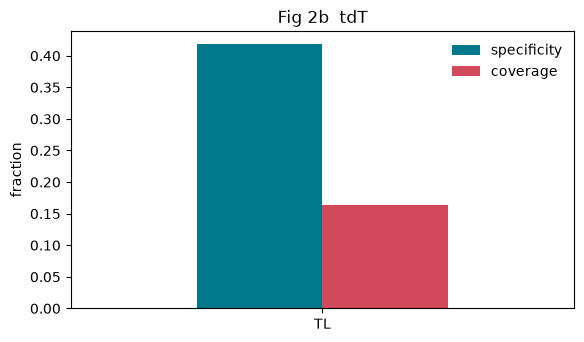

In [8]:
for (figure, reporter), block in summary.groupby(level=[0, 1]):
    block = block.droplevel([0, 1])
    ax = block[["specificity", "coverage"]].plot(kind="bar", figsize=(6.5, 3.6),
                                                 color=["#00798c", "#d1495b"], rot=0)
    ax.set_title(f"{figure}  {reporter}")
    ax.set_ylabel("fraction"); ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.show()

## Interpretation

- **Dice / Jaccard** summarise agreement in one symmetric number, but they blur two
  different failures together. **Specificity** and **coverage** separate them and
  are the interpretable pair.
- The virus cut is stricter than CD31's, so the virus mask keeps mostly its
  brightest, vessel-associated signal — that is why specificity here (~0.6) is far
  above the ~0.17 you get by segmenting the virus at CD31's own threshold. Pushing
  `VIRUS_HIGH` higher trades still-higher specificity for less coverage.
- **Even tuned, the virus mask cannot trace the CD31 network** — much of the virus
  is genuinely non-vascular. For the specificity claim, prefer the enrichment
  measure, which never segments the virus → see `enrichment_metrics.ipynb`.